# Imports Section

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from itertools import combinations

In [ ]:
PARAMS = {
    "pop_size": 30,
    "num_sensors": 10,
    "generations": 30,
    "mutation_start": 0.4,
    "mutation_end": 0.05,
    "crossover_start": 0.9,
    "crossover_end": 0.5,
    "radius": 5
}

# Loading Dataset

In [ ]:
df = pd.read_csv("/content/metr_la_reduced.csv")
df.head()

,timestamp,sensor_id,speed,traffic_level,index,latitude,longitude
0,2012-05-28 17:40:00,717510,0.000000,2,180,34.17128,-118.51976
1,2012-04-10 05:50:00,764766,65.222222,0,68,34.13338,-118.35350
2,2012-05-09 20:00:00,767350,65.444444,0,88,34.18011,-118.47045
3,2012-04-15 20:30:00,765176,68.375000,0,74,34.13286,-118.35135
4,2012-06-12 11:10:00,773013,55.111111,0,30,34.08374,-118.22076




---


#**1] Problem Modelling & Dataset Processing**


---



# Grid Design

In [ ]:
grid_size = 50

# 1) Boundary extraction
min_lat, max_lat = df["latitude"].min(), df["latitude"].max()
min_lon, max_lon = df["longitude"].min(), df["longitude"].max()

df.dropna(subset=['latitude', 'longitude'], inplace=True)

# 2) Convert Lat → X
df["x"] = np.floor(
    (df["latitude"] - min_lat) /
    (max_lat - min_lat + 1e-9) * grid_size
).astype(int)

# 3) Convert Lon → Y
df["y"] = np.floor(
    (df["longitude"] - min_lon) /
    (max_lon - min_lon + 1e-9) * grid_size
).astype(int)

# 4) Prevent out-of-bounds movement within the grid (IMPORTANT)
df["x"] = df["x"].clip(0, grid_size - 1) # X range: 0 → 49
df["y"] = df["y"].clip(0, grid_size - 1) # Y range: 0 → 49


In [ ]:
# 5) Result verification
print("Grid created")
print(df[["latitude", "longitude", "x", "y"]].head())

Grid created
   latitude  longitude   x   y
0  34.17128 -118.51976  35   2
1  34.13338 -118.35350  25  25
2  34.18011 -118.47045  38   9
3  34.13286 -118.35135  25  26
4  34.08374 -118.22076  11  44


# Sensor Distribution Map

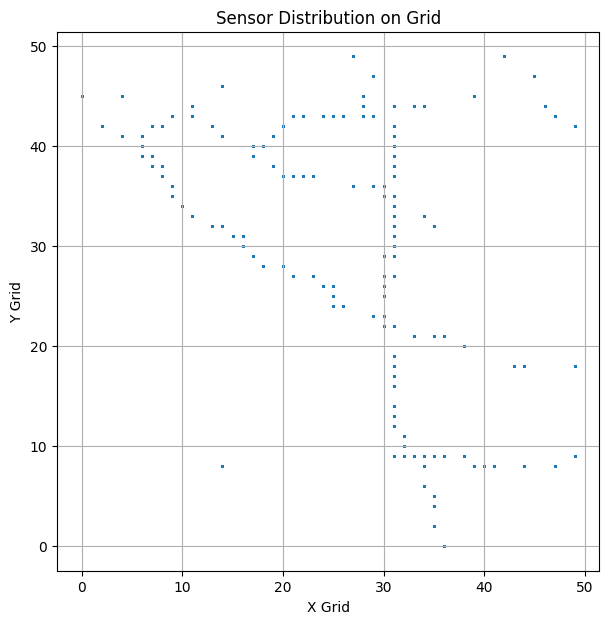

In [ ]:
#visualization
plt.figure(figsize=(7,7))

plt.scatter(
    df["x"],
    df["y"],
    s=1,
    alpha=0.5
)

plt.title("Sensor Distribution on Grid")
plt.xlabel("X Grid")
plt.ylabel("Y Grid")
plt.grid(True)

plt.show()

# Heat Map

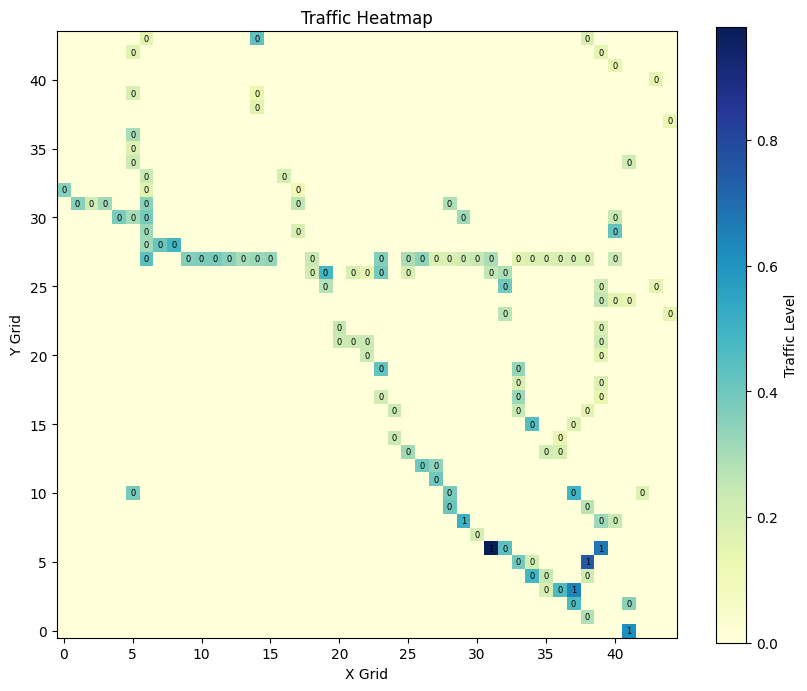

In [ ]:
#Heatmap (Traffic Intensity)
heatmap = df.groupby(["x", "y"])["traffic_level"].mean().unstack()
density = df.groupby(["x", "y"]).size().unstack().fillna(0)

high_traffic = df[df["traffic_level"] == 2]
heat_high = high_traffic.groupby(["x", "y"]).size().unstack()

plt.figure(figsize=(10,8))

# heatmap values
data = heatmap.fillna(0).values

plt.imshow(
    data,
    origin="lower",
    cmap="YlGnBu",
)

plt.colorbar(label="Traffic Level")

plt.title("Traffic Heatmap")
plt.xlabel("X Grid")
plt.ylabel("Y Grid")


for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if data[i, j] != 0:
            plt.text(
                j, i,
                f"{data[i, j]:.0f}",
                ha='center',
                va='center',
                fontsize=6,
                color='black'
            )

plt.show()

# Sensor Density Map

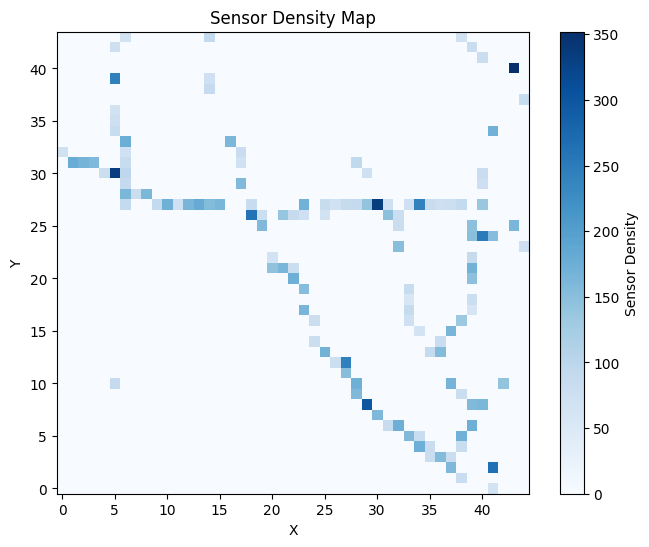

In [ ]:
plt.figure(figsize=(8,6))

plt.imshow(
    density,
    origin="lower",
    cmap="Blues",
    interpolation="nearest"
)

plt.colorbar(label="Sensor Density")
plt.title("Sensor Density Map")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

# High Traffic Only Map

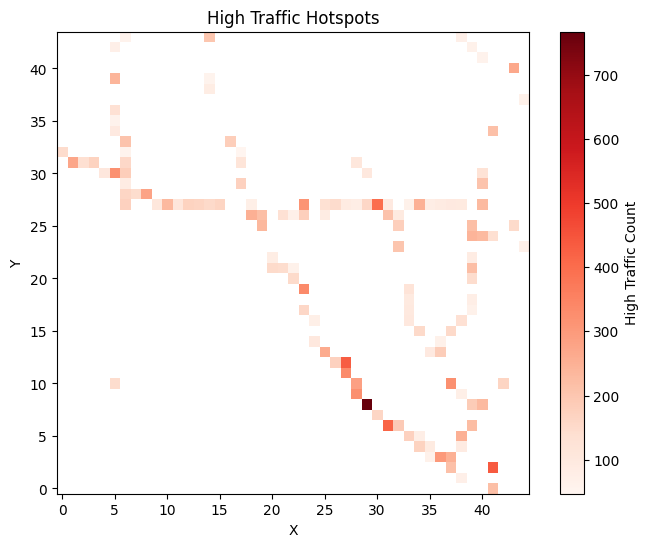

In [ ]:
plt.figure(figsize=(8,6))

plt.imshow(
    heat_high,
    origin="lower",
    cmap="Reds",
    interpolation="nearest"
)

plt.colorbar(label="High Traffic Count")
plt.title("High Traffic Hotspots")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

# Combined Visualization Map

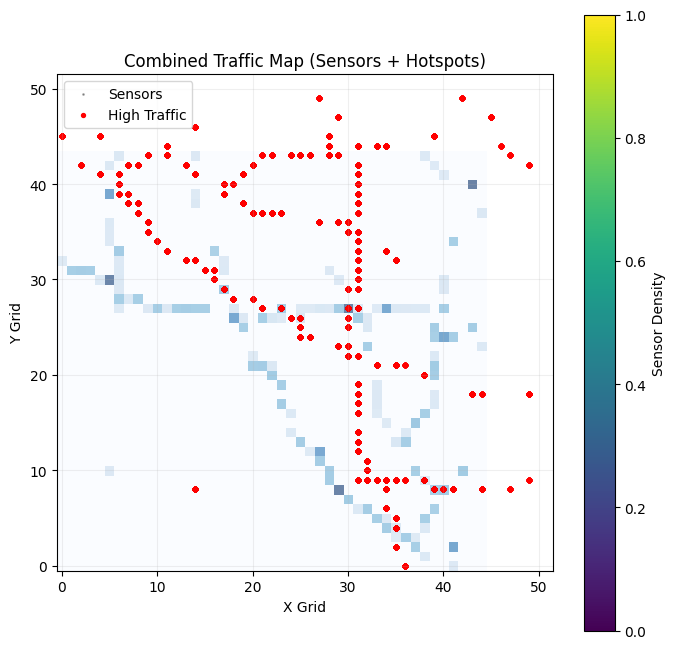

In [ ]:
plt.figure(figsize=(8,8))

# ======================
# 1) Heatmap (background)
# ======================
grid = df.groupby(["x","y"]).size().unstack().fillna(0)

plt.imshow(
    grid,
    origin="lower",
    cmap="Blues",
    alpha=0.6
)

# ======================
# 2) Sensors
# ======================
plt.scatter(
    df["x"],
    df["y"],
    s=1,
    alpha=0.3,
    color="black",
    label="Sensors"
)

# ======================
# 3) High Traffic
# ======================
high_traffic = df[df["traffic_level"] == 2]

plt.scatter(
    high_traffic["x"],
    high_traffic["y"],
    s=8,
    color="red",
    label="High Traffic"
)

# ======================
# Final touches
# ======================
plt.colorbar(label="Sensor Density")
plt.title("Combined Traffic Map (Sensors + Hotspots)")
plt.xlabel("X Grid")
plt.ylabel("Y Grid")
plt.legend()
plt.grid(alpha=0.2)

plt.show()



---


# **2] Fitness Function & Covering Simulation**


---



In [ ]:
# Convert Heatmap Into Numerical Grid

grid = heatmap.fillna(0).values
n, m = grid.shape
RADIUS = PARAMS["radius"]
print(grid)
grid.shape

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


(44, 45)

In [ ]:
# Measuring the coverage
def coverage(chromosome, grid, R=RADIUS):

    n, m = grid.shape

    covered = set()
    coverage_count = [[0]*m for _ in range(n)]
    sensor_covering = {}

    for (si, sj) in chromosome:
        sensor_cells = set()

        for i in range(max(0, si-R), min(n, si+R+1)):
           for j in range(max(0, sj-R), min(m, sj+R+1)):
               d = ((si - i)**2 + (sj - j)**2) ** 0.5  # Euclidean Distance

               if d <= R:
                 covered.add((i, j)) #track unique covered cells
                 sensor_cells.add((i, j)) # track coverage per sensor
                 coverage_count[i][j] += 1 # track overlapping

        sensor_covering[(si, sj)] = sensor_cells

    total_coverage = sum(grid[i][j] for (i, j) in covered)

    return total_coverage, coverage_count, covered, sensor_covering

In [ ]:
def get_overlap_pairs(sensor_covering):

    overlap_map = {}

    sensors = list(sensor_covering.keys())

    for s1, s2 in combinations(sensors, 2):
        overlap = sensor_covering[s1] & sensor_covering[s2]

        if overlap:
            overlap_map.setdefault(s1, []).append(s2)

    return overlap_map

In [ ]:
def compute_overlap(grid, coverage_count):

    overlap = 0

    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            if coverage_count[i][j] > 1:
                overlap += grid[i][j]

    return overlap  # Redundancy Penalty


def compute_uncovered(grid, covered):

    uncovered = 0

    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            if (i, j) not in covered:
                uncovered += grid[i][j]

    return uncovered


# Constraint: minimum distance between sensors
""" def distance_penalty(chromosome, min_dist=3):

    penalty = 0
    for i in range(len(chromosome)):
        for j in range(i+1, len(chromosome)):
            d = np.linalg.norm(np.array(chromosome[i]) - np.array(chromosome[j]))
            if d < min_dist:
                penalty += 1
    return penalty """


def fitness(chromosome, grid, R=5,
            alpha=0.6, beta=0.2, gamma=0.1, delta=0.1):
  """ max_coverage = grid.sum()
  max_uncovered = grid.sum()
  max_overlap = grid.sum() * len(chromosome)
  max_sensors = len(set(zip(df["x"], df["y"]))) """

  total_coverage, coverage_count, covered, _ = coverage(chromosome, grid, R)

  overlap = compute_overlap(grid, coverage_count)
  uncovered = compute_uncovered(grid, covered)

  fitness_value = alpha * total_coverage - beta * overlap - gamma * len(chromosome) - delta * uncovered
  # (gamma) minimize num of sensors -> represents the cost
  # (beta)  penalizes redundancy
  # (alpha) Encourages covering high-traffic cells
  # (delta) Penalizes missing important areas

  return max(0,  fitness_value)

In [ ]:
def generate_chromosome(num_sensors,grid_shape):
    n, m = grid_shape
    return [
        (random.randint(0, n-1), random.randint(0, m-1))
        for _ in range(num_sensors)
    ]

In [ ]:
def visualize(chromosome, covered,overlap_map):

    sx = [x for x, y in chromosome]
    sy = [y for x, y in chromosome]

    cx = [x for x, y in covered]
    cy = [y for x, y in covered]

    zx=[x for x, y in overlap_map]
    zy=[y for x, y in overlap_map]


    plt.figure(figsize=(8,8))

    plt.scatter(cx, cy, s=5, alpha=0.4, label="Covered")
    plt.scatter(sx, sy, c='red', s=80, label="Sensors")
    plt.scatter(zx, zy, c='black', s=80, label="overlaped")

    plt.title("Sensor Coverage")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid()
    plt.show()



---

# **3] Intialization & Selection**


---



# Intialization

Random Intialization

In [ ]:
def random_init(pop_size, num_sensors, grid_shape):
    n, m = grid_shape

    return [
        [(random.randint(0,n-1), random.randint(0,m-1))
         for _ in range(num_sensors)]
        for _ in range(pop_size)
    ]

Heuristic Initialization

In [ ]:
# biased initalization (focus on promising reigons + keeps randomness)
def heuristic_init(pop_size, num_sensors, grid):

    flat = []

    for i in range(len(grid)):
        for j in range(len(grid[0])):
            flat.append((i, j, grid[i][j])) # flatten grid

    flat.sort(key=lambda x: x[2], reverse=True) #  Sort by traffic
    top_cells = [(i, j) for i, j, _ in flat[:100]] # Top 100 cells
    population = []

    for _ in range(pop_size):
        chromosome = random.sample(top_cells, num_sensors)
        population.append(chromosome)

    return population

# Selections

Tournament Selection

In [ ]:
def tournament_selection(population, fitnesses, k=3):

    selected = []

    for _ in range(len(population)):

        idx = random.sample(range(len(population)), k)

        best = idx[0]
        for i in idx:
            if fitnesses[i] > fitnesses[best]:
                best = i

        selected.append(population[best])

    return selected

Roulette Wheel Selection

In [ ]:
def roulette_selection(population, fitnesses):
    min_fit = min(fitnesses)

    shifted = [f - min_fit + 1e-6 for f in fitnesses] # shift negative values to positive

    total = sum(shifted)

    if total == 0:
        return random.choices(population, k=len(population)) # if fitnesses are zero -> pure random selection

    probs = [f / total for f in shifted]

    return random.choices(population, weights=probs, k=len(population)) # selection by probabilities , weak indv can have chance to be selected

SUS (Stochastic Universal Sampling)

In [ ]:
def sus_selection(population, fitnesses):

    min_fit = min(fitnesses)
    shifted = [f - min_fit + 1e-6 for f in fitnesses]

    total = sum(shifted)

    if total == 0:
        return random.sample(population, len(population))

    probs = [f / total for f in shifted]

    cum = np.cumsum(probs) # Cumulative probabilities

    N = len(population)
    start = random.random() / N # random Starting Point
    pointers = [start + i*(1/N) for i in range(N)] # Even spaced pointers

    selected = []

    for p in pointers:
        for i in range(len(cum)):
            if p <= cum[i]:
                selected.append(population[i])
                break

    return selected

Over-Selection

In [ ]:
def over_selection(population, fitnesses, top_ratio=0.5, elite_pressure=0.8):

    # sort population by fitness (best → worst)
    idx = np.argsort(fitnesses)[::-1]
    sorted_pop = [population[i] for i in idx]


    split = int(len(population) * top_ratio)

    top_group = sorted_pop[:split]
    bottom_group = sorted_pop[split:]

    selected = []

    # build new parent pool
    for _ in range(len(population)):

        if random.random() < elite_pressure:
            selected.append(random.choice(top_group))
        else:
            selected.append(random.choice(bottom_group))

    return selected

#Elitism

In [ ]:
def elitism(population, fitnesses, elite_size=2):
    idx = np.argsort(fitnesses)[::-1]
    elite = [population[i] for i in idx[:elite_size]]
    return elite    # Too much elitism cause premature convergence

# Generational Replacement



In [ ]:
"""def generational_replacement(offspring, elite, pop_size):
    new_population = elite + offspring
    return new_population[:pop_size]""" # take elites from old solution and also new solutions

'def generational_replacement(offspring, elite, pop_size):\n    new_population = elite + offspring\n    return new_population[:pop_size]'

#Rank-Based Survivor Selection


In [ ]:
def rank_based_survivor(population, fitnesses):

    idx = np.argsort(fitnesses)
    sorted_pop = [population[i] for i in idx]
    weights = np.arange(1, len(population)+1) # assign ranks
    probs = weights / sum(weights) # convert them to probabilities
    selected_idx = np.random.choice(
        len(population),
        size=len(population),
        p=probs
    ) # select survivors

    return [sorted_pop[i] for i in selected_idx]

In [ ]:
def evaluate_population(population, grid, R=5):

    return [fitness(ind, grid, R) for ind in population] # compute fitnesses for all indv

In [ ]:
def adaptive_tournament_k(gen, generations):

    return max(2, int(5 * (1 - gen / generations))) # adaptive selection pressure from high to low -> early gen (accelerates convergence), late gen (prevent premature convergence)



---

# **4] Crossover & Mutation & Diversity**

---



In [ ]:
def repair(individual, grid_shape, num_sensors):

    n, m = grid_shape

    repaired = [(int(x), int(y)) for x, y in individual]

    repaired = list(dict.fromkeys(repaired))  # remove duplicates only

    # instead of random filling → reuse existing structure
    while len(repaired) < num_sensors:
        repaired.append(random.choice(repaired))

    return repaired[:num_sensors]


def one_point_crossover(p1, p2, num_sensors, grid):

    point = num_sensors // 2
    child = p1[:point] + p2[point:]

    return repair(child, grid.shape, num_sensors)

def uniform_crossover(p1, p2, num_sensors, grid):

    child = []

    for i in range(num_sensors):
        gene = p1[i] if random.random() < 0.5 else p2[i]
        if gene not in child:
            child.append(gene)

    return repair(child, grid.shape, num_sensors)

In [ ]:
def random_shift(individual, grid, mutation_rate=0.2):  # Moves sensor slightly in nearby grid area

    new_ind = individual.copy()

    for i in range(len(new_ind)):
        if random.random() < mutation_rate:

            x, y = new_ind[i]
            # shift position
            nx = max(0, min(grid.shape[0] - 1, x + random.randint(-2, 2))) # boundary control to keep sensor inside the grid
            ny = max(0, min(grid.shape[1] - 1, y + random.randint(-2, 2)))

            new_ind[i] = (nx, ny)

    return repair(new_ind, grid.shape, len(individual))

# RANDOM RESET MUTATION -> Completely replaces a gene with a random position
def random_reset(individual, grid, mutation_rate=0.2):

    new_ind = individual.copy()

    for i in range(len(new_ind)):
        if random.random() < mutation_rate:
            # generate random position
            nx = random.randint(0, grid.shape[0] - 1)
            ny = random.randint(0, grid.shape[1] - 1)

            new_ind[i] = (nx, ny)

    return repair(new_ind, grid.shape, len(individual))

In [ ]:
# low diversity -> premature convergence
# high diversity -> more exploration
def diversity_basic(population, threshold=0.8):

    new_pop = []

    for ind in population:

        keep = True

        for kept in new_pop:
            similarity = len(set(ind) & set(kept)) / len(ind)

            if similarity > threshold:
                keep = False
                break

        if keep:
            new_pop.append(ind)

    return new_pop if len(new_pop) > 0 else population


# STRONG DIVERSITY
def diversity_strong(population, threshold=0.6):

    new_pop = []

    for ind in population:

        keep = True

        for kept in new_pop:
            similarity = len(set(ind) & set(kept)) / len(ind)

            if similarity > threshold:
                keep = False
                break

        if keep:
            new_pop.append(ind)

    return new_pop if len(new_pop) >= 2 else population

In [ ]:
def adaptive_crossover(gen, generations):
    start = 0.9
    end = 0.5
    return start - (start - end) * (gen / generations)
    # early -> exploration , low -> stability

In [ ]:
def adaptive_mutation(gen, generations):
    start = 0.2
    end = 0.1
    return start - (start - end) * (gen / generations)

---

# **5] GA LOOP**

---

In [ ]:
def log_parameters(gen, mutation_rate, crossover_rate, k):

    print(f"""
    Generation {gen}
    Mutation Rate   : {mutation_rate:.3f}
    Crossover Rate  : {crossover_rate:.3f}
    Tournament K    : {k}
    """)

In [ ]:
def run_ga(grid,
           pop_size=30,
           num_sensors=10,
           generations=30,

           selection_method="roulette",
           crossover_type="uniform",
           mutation_type="shift",
           diversity_type="strong",
           survivor_method="rank",
           init_method="random",

           use_de=False,
           de_F=0.5,
           de_CR=0.7,
           de_apply_rate=0.5,

           seed=None):

    # SEED
    if seed is not None:
      random.seed(seed)
      np.random.seed(seed)

    # INIT
    if init_method == "random":
       population = random_init(pop_size, num_sensors, grid.shape)
    else:
       population = heuristic_init(pop_size, num_sensors, grid)

    snapshots = []
    best_history = []
    avg_history = []
    diversity_history = []
    best_chromosome = None # Initialize best_chromosome

    elite_size = 4
    snapshot_gens = [0, generations // 2, generations - 1]


    # MAIN LOOP
    for gen in range(generations):


        # ADAPTIVE CONTROL
        mutation_rate = adaptive_mutation(gen, generations)
        crossover_rate = adaptive_crossover(gen, generations)
        k = max(2, min(10, adaptive_tournament_k(gen, generations) + 2))
        log_parameters(gen, mutation_rate, crossover_rate, k)


        # FITNESS (of current generation's population)
        fitnesses = evaluate_population(population, grid, R=PARAMS["radius"])


        # SELECTION (parents from current generation)
        if selection_method == "tournament":
           parents = tournament_selection(population, fitnesses, k)
        elif selection_method == "roulette":
           parents = roulette_selection(population, fitnesses)
        elif selection_method == "sus":
           parents = sus_selection(population, fitnesses)
        elif selection_method == "over":
           parents = over_selection(population, fitnesses)
        else:
           parents = tournament_selection(population, fitnesses, k)

        # protect the best
        current_elites = elitism(population, fitnesses, elite_size)

        # OFFSPRING GENERATION
        offspring_generated = []

        # Generate non-elite offspring to fill the remaining population slots
        while len(offspring_generated) < pop_size - elite_size:


            if len(parents) < 2:
                # If too few parents, duplicate one or take a random one from original population
                p1 = random.choice(parents) if parents else generate_chromosome(num_sensors, grid.shape)
                p2 = random.choice(parents) if parents else generate_chromosome(num_sensors, grid.shape)
                if len(parents) == 1: # If only one parent, ensure p2 is different if possible
                    p2 = random.choice(population) if population else generate_chromosome(num_sensors, grid.shape)
            else:
                p1, p2 = random.sample(parents, 2)

            # Crossover
            if random.random() < crossover_rate:
                if crossover_type == "onepoint":
                    child = one_point_crossover(p1, p2, num_sensors, grid)
                else:
                    child = uniform_crossover(p1, p2, num_sensors, grid)
            else:
                child = p1.copy()

            # Mutation
            if mutation_type == "shift":
                child = random_shift(child, grid, mutation_rate)
            else:
                child = random_reset(child, grid, mutation_rate)

            offspring_generated.append(child)

        # Combine the newly generated offspring with the elites from the previous generation
        candidate_next_population = offspring_generated + current_elites

        # DIVERSITY
        if diversity_type == "basic":
            candidate_next_population = diversity_basic(candidate_next_population)
        else:
            candidate_next_population = diversity_strong(candidate_next_population)

        # Ensure the candidate population is not too small after diversity application
        while len(candidate_next_population) < pop_size:
            # Refill with a random parent or a newly generated chromosome
            if parents:
                candidate_next_population.append(random.choice(parents))
            else:
                candidate_next_population.append(generate_chromosome(num_sensors, grid.shape))

        # SURVIVOR SELECTION: Form the actual 'population' for the next generation
        if survivor_method == "elitism":
           population = candidate_next_population[:pop_size]
        elif survivor_method == "rank":
           # Need to evaluate fitness of the candidate next population for rank-based selection
           candidate_fitnesses = evaluate_population(candidate_next_population, grid, R=PARAMS["radius"])
           population = rank_based_survivor(candidate_next_population, candidate_fitnesses)[:pop_size]
        else:
           population = candidate_next_population[:pop_size]


        #  OPTIONAL DE STEP (HYBRID PLUG)
        if use_de:
            vector_pop = [encode(ind) for ind in population]
            current_pop_len = len(vector_pop)

            # Only apply DE if there are enough individuals for mutation operation (need at least 4 distinct individuals)
            if current_pop_len >= 4:
                n_de_to_apply = int(de_apply_rate * current_pop_len)
                n_de_to_apply = min(n_de_to_apply, current_pop_len)

                for i in random.sample(range(current_pop_len), n_de_to_apply):
                    mutant = de_mutation(vector_pop, i, de_F)
                    trial = de_crossover(vector_pop[i], mutant, de_CR)

                    trial_chrom = repair_de(decode(trial), grid.shape, num_sensors)
                    target_chrom = repair_de(decode(vector_pop[i]), grid.shape, num_sensors)

                    if fitness(trial_chrom, grid) > fitness(target_chrom, grid): # Compare fitness of repaired chromosomes
                        vector_pop[i] = trial

                population = [
                    repair_de(decode(v), grid.shape, num_sensors)
                    for v in vector_pop
                ]



        if gen % 5 == 0 and len(population) < pop_size:
            population.append(generate_chromosome(num_sensors, grid.shape))

        population = population[:pop_size]
        div_val = population_diversity(population)
        diversity_history.append(div_val)

        print(f"Diversity = {div_val:.4f}")

        fitnesses = evaluate_population(population, grid, R=PARAMS["radius"])

        best_gen_fitness = max(fitnesses)
        avg_gen_fitness = np.mean(fitnesses)
        best_gen_idx = np.argmax(fitnesses)


        # Update overall best chromosome
        if not best_history or best_gen_fitness > max(best_history):
            best_chromosome = population[best_gen_idx]

        best_history.append(best_gen_fitness)
        avg_history.append(avg_gen_fitness)
        if gen in [0, generations//2, generations-1]:
                   snapshots.append((gen, best_chromosome))


        # logging
        print(
            f"[GA{'+DE' if use_de else ''}] Gen {gen:02d} | "
            f"Best={best_gen_fitness:.4f} | Avg={avg_gen_fitness:.4f}"
        )

    return max(best_history), best_history, avg_history, best_chromosome, diversity_history, snapshots

---

# **6] Differential Evolution & DE LOOP**

---

In [ ]:
def encode(chromosome):
    # [(x,y), (x,y)] → [x1,y1,x2,y2,...]
    return np.array([coord for point in chromosome for coord in point])


def decode(vector):
    # [x1,y1,x2,y2,...] → [(x,y),(x,y)]
    return [(int(vector[i]), int(vector[i+1]))
            for i in range(0, len(vector), 2)]

In [ ]:
# This repair function: fixes boundaries & fixes float → int
def repair_de(individual, grid_shape, num_sensors):

    n, m = grid_shape

    repaired = []
    for x, y in individual:
        x = int(np.clip(x, 0, n-1))
        y = int(np.clip(y, 0, m-1))
        repaired.append((x, y))

    repaired = list(dict.fromkeys(repaired))

    while len(repaired) < num_sensors:
        repaired.append((random.randint(0,n-1), random.randint(0,m-1)))

    return repaired[:num_sensors]

# Mutation

In [ ]:
# v = x1 + F * (x2 - x3)
def de_mutation(population_vectors, i, F=0.5):

    idxs = list(range(len(population_vectors)))
    idxs.remove(i)

    a, b, c = random.sample(idxs, 3)

    x1 = population_vectors[a]
    x2 = population_vectors[b]
    x3 = population_vectors[c]

    mutant = x1 + F * (x2 - x3)

    return mutant



# Crossover

In [ ]:
def de_crossover(target, mutant, CR=0.7):

    trial = np.copy(target)

    for i in range(len(target)):
        if random.random() < CR:
            trial[i] = mutant[i]

    return trial

#DE loop

In [ ]:
def run_de(grid,
           pop_size=30,
           num_sensors=10,
           generations=30,
           seed=None):

    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    population = [
        encode(generate_chromosome(num_sensors, grid.shape))
        for _ in range(pop_size)
    ]

    best_history = []
    avg_history = []
    diversity_history = []
    snapshots = []

    best_chromosome = None
    best_fitness_so_far = -float("inf")

    dim = num_sensors * 2

    for gen in range(generations):

        F = 0.3 + 0.4 * random.random()
        CR = 0.6 + 0.3 * (gen / generations)

        new_population = []

        for i in range(pop_size):

            x = population[i]
            idxs = list(range(pop_size))
            idxs.remove(i)

            a, b, c = random.sample(idxs, 3)

            x1 = population[a]
            x2 = population[b]
            x3 = population[c]

            mutant = x1 + F * (x2 - x3)

            trial = np.copy(x)

            for j in range(dim):
                if random.random() < CR:
                    trial[j] = mutant[j]

            trial_chrom = repair(decode(trial), grid.shape, num_sensors)
            target_chrom = repair(decode(x), grid.shape, num_sensors)

            if fitness(trial_chrom, grid) > fitness(target_chrom, grid):
                new_population.append(trial)
            else:
                new_population.append(x)

        population = new_population

        # ===== FITNESS =====
        fitnesses = [
            fitness(repair(decode(ind), grid.shape, num_sensors), grid)
            for ind in population
        ]

        best = max(fitnesses)
        avg = np.mean(fitnesses)

        best_history.append(best)
        avg_history.append(avg)

        # ===== DIVERSITY =====
        diversity_history.append(population_diversity(population))

        # ===== BEST CHROMOSOME FIX =====
        best_idx = np.argmax(fitnesses)

        if fitnesses[best_idx] > best_fitness_so_far:
            best_fitness_so_far = fitnesses[best_idx]
            best_chromosome = repair(
                decode(population[best_idx]),
                grid.shape,
                num_sensors
            )

        # ===== SNAPSHOT =====
        snapshots.append((gen, best_chromosome))

        print(f"[DE] Gen {gen:02d} | Best={best:.4f} | Avg={avg:.4f}")

    return max(best_history), best_history, avg_history, best_chromosome, diversity_history, snapshots

In [ ]:
"""def run_experiments(grid, runs=10):


    de_results = []
    ga_best = 0 # Initialize ga_best here

    for r in range(runs):

        print("\n" + "="*50)
        print(f"RUN {r+1}/{runs}")
        print("="*50)


        # =========================
        # DE ONLY
        # =========================
        print("\n[DE] Running...")
        de_best, de_hist, _ = run_de(grid)
        de_results.append(de_best)
        print(f"[DE] Best Fitness = {de_best:.4f}")



        # =========================
        # RUN SUMMARY
        # =========================
        print("\n--- RUN SUMMARY ---")
        print(f"DE      : {de_best:.4f}")


    return  de_results"""

'def run_experiments(grid, runs=10):\n\n\n    de_results = []\n    ga_best = 0 # Initialize ga_best here\n\n    for r in range(runs):\n\n        print("\n" + "="*50)\n        print(f"RUN {r+1}/{runs}")\n        print("="*50)\n\n\n        # =========================\n        # DE ONLY\n        # =========================\n        print("\n[DE] Running...")\n        de_best, de_hist, _ = run_de(grid)\n        de_results.append(de_best)\n        print(f"[DE] Best Fitness = {de_best:.4f}")\n\n\n\n        # =========================\n        # RUN SUMMARY\n        # =========================\n        print("\n--- RUN SUMMARY ---")\n        print(f"DE      : {de_best:.4f}")\n\n\n    return  de_results'

---

# **7] Experiments & Helper Functions**

---

In [ ]:
def get_coverage_map(chromosome, grid, R):

    n, m = grid.shape
    covered = set()

    for (si, sj) in chromosome:
        for i in range(max(0, si-R), min(n, si+R+1)):
            for j in range(max(0, sj-R), min(m, sj+R+1)):
                if np.linalg.norm([si-i, sj-j]) <= R:
                    covered.add((i, j))

    return covered

In [ ]:
def coverage_ratio(chromosome, grid, R):
    covered = get_coverage_map(chromosome, grid, R)
    total_cells = grid.shape[0] * grid.shape[1]
    return len(covered) / total_cells

In [ ]:
def population_diversity(population):
    arr = np.array([np.array(ind).flatten() for ind in population])
    return np.mean(np.std(arr, axis=0))

In [ ]:
from joblib import Parallel, delayed

# =========================
# PARALLEL HELPERS
# =========================

def single_run_ga_full(grid, sel, cross, mut, div, init, surv, sensors, algo, seed):
    best, hist, avg, best_chrom, div_hist, snapshots = run_ga(
     grid,
     selection_method=sel,
     crossover_type=cross,
     mutation_type=mut,
     diversity_type=div,
     survivor_method=surv,
     init_method=init,
     num_sensors=sensors,
     use_de=(algo == "HYBRID"),
     seed=seed
    )

    cov = coverage_ratio(best_chrom, grid, PARAMS["radius"])

    return best, hist, div_hist, snapshots, cov

def single_run_de_full(grid, sensors, seed):

    best, hist, avg, best_chrom, div_hist, snapshots = run_de(
        grid,
        num_sensors=sensors,
        seed=seed
    )

    cov = coverage_ratio(best_chrom, grid, PARAMS["radius"])

    return best, hist, div_hist, snapshots, cov


# =========================
# MAIN EXPERIMENT FUNCTION
# =========================

def run_experiments(grid, runs=10):

    results = []

    selection_methods = ["tournament", "roulette", "sus", "over"]
    crossover_types = ["onepoint", "uniform"]
    mutation_types = ["shift", "reset"]
    diversity_types = ["basic", "strong"]

    init_methods = ["random", "heuristic"]
    survivor_methods = ["elitism", "rank"]
    sensor_values = [5, 10, 15]

    algorithms = ["GA", "DE", "HYBRID"]

    all_histories = {
        "GA": [],
        "DE": [],
        "HYBRID": []
    }
    all_snapshots = {
        "GA": [],
        "DE": [],
        "HYBRID": []
    }
    all_diversity = {
        "GA": [],
        "DE": [],
        "HYBRID": []
    }

    for algo in algorithms:

        print("\n" + "#"*70)
        print(f"ALGORITHM: {algo}")
        print("#"*70)

        # =========================
        # GA & HYBRID
        # =========================
        if algo in ["GA", "HYBRID"]:

            for sel in selection_methods:
                for cross in crossover_types:
                    for mut in mutation_types:
                        for div in diversity_types:
                            for init in init_methods:
                                for surv in survivor_methods:
                                    for sensors in sensor_values:

                                        print(f"\nCONFIG: {sel}|{cross}|{mut}|{div}|{init}|{surv}|S={sensors}")


                                        # generate seeds once

                                        seeds = [random.randint(0, 100000) for _ in range(runs)]
                                        print("\nSeed list per run:")
                                        for i, s in enumerate(seeds):
                                                print(f"Run {i+1}: Seed = {s}")

                                        # PARALLEL EXECUTION
                                        results_parallel = Parallel(n_jobs=-1)(
                                            delayed(single_run_ga_full)(
                                                grid, sel, cross, mut, div, init, surv, sensors, algo, seed
                                            )
                                            for seed in seeds
                                        )

                                        scores = [r[0] for r in results_parallel]
                                        hist_collection = [r[1] for r in results_parallel]
                                        coverages = [r[2] for r in results_parallel]
                                        snapshots_collection = [r[3] for r in results_parallel]
                                        div_collection = [r[4] for r in results_parallel]



                                        avg_hist = np.mean(hist_collection, axis=0)
                                        all_histories[algo].append(avg_hist)
                                        all_diversity[algo].append(np.mean(div_collection, axis=0))
                                        all_snapshots[algo].append({
                                               "config": (sel, cross, mut, div, init, surv, sensors),
                                               "runs": snapshots_collection
                                        })



                                        print(f"Mean = {np.mean(scores):.4f} | Max = {np.max(scores):.4f}")

                                        results.append({
                                            "algorithm": algo,
                                            "selection": sel,
                                            "crossover": cross,
                                            "mutation": mut,
                                            "diversity": div,
                                            "init": init,
                                            "survivor": surv,
                                            "sensors": sensors,
                                            "mean": np.mean(scores),
                                            "std": np.std(scores),
                                            "max": np.max(scores),
                                            "seeds": [{"run": i, "seed": s} for i, s in enumerate(seeds)],
                                            "scores": scores
                                        })

        # =========================
        # DE ONLY
        # =========================
        else:

            for sensors in sensor_values:

                print(f"\nCONFIG: DE | Sensors={sensors}")

                seeds = [random.randint(0, 100000) for _ in range(runs)]

                results_parallel = Parallel(n_jobs=-1)(
                    delayed(single_run_de_full)(grid, sensors, seed)
                    for seed in seeds
                )

                scores = [r[0] for r in results_parallel]
                hist_collection = [r[1] for r in results_parallel]
                coverages = [r[2] for r in results_parallel]

                avg_hist = np.mean(hist_collection, axis=0)
                all_histories[algo].append(avg_hist)

                print(f"Mean = {np.mean(scores):.4f} | Max = {np.max(scores):.4f}")

                results.append({
                    "algorithm": "DE",
                    "sensors": sensors,
                    "mean": np.mean(scores),
                    "std": np.std(scores),
                    "max": np.max(scores),
                    "seeds": seeds
                })

    return results, all_histories, all_diversity, all_snapshots

In [ ]:
best_hybrid, hist_hybrid, avg_hybrid, hybrid_best_solution, div_hist, snapshots = run_ga(
    generations=30,
    num_sensors=15
    grid=grid,
    use_de=True
)


    Generation 0
    Mutation Rate   : 0.200
    Crossover Rate  : 0.900
    Tournament K    : 7
    
Diversity = 10.5427
[GA+DE] Gen 00 | Best=13.4531 | Avg=10.7792

    Generation 1
    Mutation Rate   : 0.197
    Crossover Rate  : 0.887
    Tournament K    : 6
    
Diversity = 9.7440
[GA+DE] Gen 01 | Best=13.5045 | Avg=10.9132

    Generation 2
    Mutation Rate   : 0.193
    Crossover Rate  : 0.873
    Tournament K    : 6
    
Diversity = 9.0117
[GA+DE] Gen 02 | Best=14.3730 | Avg=11.1074

    Generation 3
    Mutation Rate   : 0.190
    Crossover Rate  : 0.860
    Tournament K    : 6
    
Diversity = 6.5692
[GA+DE] Gen 03 | Best=14.4254 | Avg=12.0606

    Generation 4
    Mutation Rate   : 0.187
    Crossover Rate  : 0.847
    Tournament K    : 6
    
Diversity = 4.7155
[GA+DE] Gen 04 | Best=15.3525 | Avg=13.1582

    Generation 5
    Mutation Rate   : 0.183
    Crossover Rate  : 0.833
    Tournament K    : 6
    
Diversity = 3.0048
[GA+DE] Gen 05 | Best=15.3525 | Avg=13.3346

  

In [ ]:
import os
import gc
import random
import pickle
from google.colab import drive

# =========================
# MOUNT DRIVE
# =========================
drive.mount('/content/drive')

checkpoint_file = "/content/drive/MyDrive/ga_checkpoint.pkl"


# =========================
# RUN EXPERIMENTS (YOUR FUNCTION MUST EXIST)
# =========================
# run_experiments(grid, runs, seeds)
# MUST RETURN:
# results, histories, diversity, snapshots


# =========================
# BATCHED EXECUTION WITH CHECKPOINT
# =========================
def run_in_batches(grid, total_runs=20, batch_size=5):

    num_batches = total_runs // batch_size

    # =========================
    # LOAD CHECKPOINT IF EXISTS
    # =========================
    if os.path.exists(checkpoint_file):
        with open(checkpoint_file, "rb") as f:
            data = pickle.load(f)

        all_results = data["results"]
        all_histories = data["histories"]
        all_diversity = data["diversity"]
        all_snapshots = data["snapshots"]
        start_batch = data["start_batch"] + 1

        print(f"\n Resuming from batch {start_batch}")

    else:
        all_results = []
        all_histories = []
        all_diversity = []
        all_snapshots = []
        start_batch = 0

    # =========================
    # BATCH LOOP
    # =========================
    for b in range(start_batch, num_batches):

        print("\n" + "="*60)
        print(f"BATCH {b+1}/{num_batches}")
        print("="*60)


        # =========================
        # RUN EXPERIMENT
        # =========================
        results, histories, diversity, snapshots = run_experiments(
            grid,
            runs=batch_size
        )

        # =========================
        # STORE RESULTS
        # =========================
        all_results.extend(results)
        all_histories.append(histories)
        all_diversity.append(diversity)
        all_snapshots.append(snapshots)

        # =========================
        # SAVE CHECKPOINT (IMPORTANT)
        # =========================
        with open(checkpoint_file, "wb") as f:
            pickle.dump({
                "results": all_results,
                "histories": all_histories,
                "diversity": all_diversity,
                "snapshots": all_snapshots,
                "start_batch": b
            }, f)

        print(f"\n Batch {b+1} saved to Drive")

        # cleanup memory
        gc.collect()

    return all_results, all_histories, all_diversity, all_snapshots

Mounted at /content/drive


In [ ]:
results, histories, diversity, snapshots = run_in_batches(
    grid,
    total_runs=20,
    batch_size=5
)

Streaming output truncated to the last 5000 lines.
Mean = 16.4656 | Max = 17.0404

CONFIG: sus|uniform|reset|basic|heuristic|elitism|S=5

Seed list per run:
Run 1: Seed = 86076
Run 2: Seed = 71145
Run 3: Seed = 23970
Run 4: Seed = 95030
Run 5: Seed = 1136
Mean = 11.2389 | Max = 12.0805

CONFIG: sus|uniform|reset|basic|heuristic|elitism|S=10

Seed list per run:
Run 1: Seed = 99873
Run 2: Seed = 99443
Run 3: Seed = 99296
Run 4: Seed = 68166
Run 5: Seed = 2367
Mean = 14.8888 | Max = 16.3788

CONFIG: sus|uniform|reset|basic|heuristic|elitism|S=15

Seed list per run:
Run 1: Seed = 28605
Run 2: Seed = 5852
Run 3: Seed = 57357
Run 4: Seed = 31190
Run 5: Seed = 64135
Mean = 15.9031 | Max = 16.3872

CONFIG: sus|uniform|reset|basic|heuristic|rank|S=5

Seed list per run:
Run 1: Seed = 10834
Run 2: Seed = 53902
Run 3: Seed = 43527
Run 4: Seed = 49214
Run 5: Seed = 16334
Mean = 10.9220 | Max = 11.5842

CONFIG: sus|uniform|reset|basic|heuristic|rank|S=10

Seed list per run:
Run 1: Seed = 70165
Run 2

In [ ]:
def resize_grid(base_df, grid_size):

    df = base_df.copy()

    min_lat, max_lat = df["latitude"].min(), df["latitude"].max()
    min_lon, max_lon = df["longitude"].min(), df["longitude"].max()

    df["x"] = np.floor(
        (df["latitude"] - min_lat) /
        (max_lat - min_lat + 1e-9) * grid_size
    ).astype(int)

    df["y"] = np.floor(
        (df["longitude"] - min_lon) /
        (max_lon - min_lon + 1e-9) * grid_size
    ).astype(int)

    df["x"] = df["x"].clip(0, grid_size - 1)
    df["y"] = df["y"].clip(0, grid_size - 1)

    grid = df.groupby(["x", "y"])["traffic_level"].mean().unstack().fillna(0).values

    return grid

In [ ]:
for size in [30, 50, 70]:

    print("\n" + "="*50)
    print(f"RUNNING GRID SIZE: {size}")
    print("="*50)

    grid_scaled = resize_grid(df, size)
    best_grid, hist_grid, avg_grid, best_sol_grid, div_grid, snaps_grid = run_ga(
        grid_scaled,
        use_de=True,
        num_sensors=10,
        generations=30,
        seed=42
    )
print(f"Final Best Fitness (size {size}): {best_grid:.4f}")


RUNNING GRID SIZE: 30

    Generation 0
    Mutation Rate   : 0.200
    Crossover Rate  : 0.900
    Tournament K    : 7
    
Diversity = 7.8645
[GA+DE] Gen 00 | Best=12.2192 | Avg=9.4311

    Generation 1
    Mutation Rate   : 0.197
    Crossover Rate  : 0.887
    Tournament K    : 6
    
Diversity = 7.5697
[GA+DE] Gen 01 | Best=12.2192 | Avg=10.0752

    Generation 2
    Mutation Rate   : 0.193
    Crossover Rate  : 0.873
    Tournament K    : 6
    
Diversity = 6.6190
[GA+DE] Gen 02 | Best=13.5172 | Avg=10.0156

    Generation 3
    Mutation Rate   : 0.190
    Crossover Rate  : 0.860
    Tournament K    : 6
    
Diversity = 5.7803
[GA+DE] Gen 03 | Best=13.5172 | Avg=11.2526

    Generation 4
    Mutation Rate   : 0.187
    Crossover Rate  : 0.847
    Tournament K    : 6
    
Diversity = 6.0419
[GA+DE] Gen 04 | Best=13.0431 | Avg=11.1742

    Generation 5
    Mutation Rate   : 0.183
    Crossover Rate  : 0.833
    Tournament K    : 6
    
Diversity = 5.1427
[GA+DE] Gen 05 | Best=13.4

---

# **7] Experimental Results Visualization**

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pickle

checkpoint_file = "/content/drive/MyDrive/ga_checkpoint.pkl"

with open(checkpoint_file, "rb") as f:
    data = pickle.load(f)

print("Checkpoint loaded successfully!")

Checkpoint loaded successfully!


In [ ]:
results = data["results"]
histories = data["histories"]
diversity = data["diversity"]
snapshots = data["snapshots"]


In [ ]:
ga_all = []
de_all = []
hy_all = []

for batch in histories:
    ga_all.extend(batch["GA"])
    de_all.extend(batch["DE"])
    hy_all.extend(batch["HYBRID"])

In [ ]:
def convergence_speed(history, window=5, eps=0.001):
    for i in range(len(history) - window):
        window_vals = history[i:i+window]
        if max(window_vals) - min(window_vals) < eps:
            return i
    return len(history)

In [ ]:
ga_best_history = max(ga_all, key=lambda x: max(x))
de_best_history = max(de_all, key=lambda x: max(x))
hybrid_best_history = max(hy_all, key=lambda x: max(x))
ga_conv = convergence_speed(ga_best_history)
de_conv = convergence_speed(de_best_history)
hy_conv = convergence_speed(hybrid_best_history)

print("GA convergence:", ga_conv)
print("DE convergence:", de_conv)
print("Hybrid convergence:", hy_conv)

GA convergence: 30
DE convergence: 9
Hybrid convergence: 30


In [ ]:
print("GA convergence:", ga_conv)
print("DE convergence:", de_conv)
print("Hybrid convergence:", hy_conv)

In [ ]:
def print_all_scores(results):

    print("\n" + "="*60)
    print("ALL FITNESS SCORES PER CONFIGURATION")
    print("="*60)

    for r in results:

        print("\n--------------------------------------")
        print(f"Algorithm : {r['algorithm']}")

        if r["algorithm"] != "DE":
            print(f"Selection : {r['selection']}")
            print(f"Crossover : {r['crossover']}")
            print(f"Mutation  : {r['mutation']}")
            print(f"Diversity : {r['diversity']}")

        print(f"Sensors   : {r['sensors']}")
        print(f"Mean      : {r['mean']:.4f}")
        print(f"Std       : {r['std']:.4f}")
        print(f"Max       : {r['max']:.4f}")

        if "scores" in r:
            print(f"\nAll Scores (runs):")
            print(r["scores"])

In [ ]:
print_all_scores(results)


ALL FITNESS SCORES PER CONFIGURATION

--------------------------------------
Algorithm : GA
Selection : tournament
Crossover : onepoint
Mutation  : shift
Diversity : basic
Sensors   : 5
Mean      : 10.9624
Std       : 1.1875
Max       : 12.2148

All Scores (runs):
[np.float64(12.214794966620516), np.float64(8.923890266645387), np.float64(11.278951574776176), np.float64(11.944374971594435), np.float64(10.449829282353948)]

--------------------------------------
Algorithm : GA
Selection : tournament
Crossover : onepoint
Mutation  : shift
Diversity : basic
Sensors   : 10
Mean      : 16.2799
Std       : 1.5125
Max       : 18.4662

All Scores (runs):
[np.float64(17.640891970520975), np.float64(15.688482060240112), np.float64(15.012870729742252), np.float64(14.591219098023398), np.float64(18.466188353801794)]

--------------------------------------
Algorithm : GA
Selection : tournament
Crossover : onepoint
Mutation  : shift
Diversity : basic
Sensors   : 15
Mean      : 18.0726
Std       : 0.

In [ ]:
def print_seeds_with_configs(results):

    print("\n" + "="*70)
    print("SEEDS PER CONFIGURATION")
    print("="*70)

    for r in results:

        print("\n" + "-"*60)

        # CONFIG HEADER
        if r["algorithm"] != "DE":
            config_name = f"{r['algorithm']} | {r['selection']} | {r['crossover']} | {r['mutation']} | {r['diversity']} | {r['init']} | {r['survivor']} | S={r['sensors']}"
        else:
            config_name = f"DE | Sensors={r['sensors']}"

        print(f"CONFIG: {config_name}")

        # SEEDS
        print("Seeds per run:")

        for s in r["seeds"]:
            if isinstance(s, dict):  # GA/HYBRID format
                print(f"Run {s['run']}: Seed = {s['seed']}")
            else:  # DE fallback (if list only)
                print(f"Seed = {s}")

In [ ]:
print_seeds_with_configs(results)

Streaming output truncated to the last 5000 lines.
Run 0: Seed = 97968
Run 1: Seed = 60410
Run 2: Seed = 12304
Run 3: Seed = 59768
Run 4: Seed = 1585

------------------------------------------------------------
CONFIG: GA | sus | onepoint | reset | basic | random | elitism | S=5
Seeds per run:
Run 0: Seed = 46274
Run 1: Seed = 36779
Run 2: Seed = 18766
Run 3: Seed = 98635
Run 4: Seed = 81185

------------------------------------------------------------
CONFIG: GA | sus | onepoint | reset | basic | random | elitism | S=10
Seeds per run:
Run 0: Seed = 29405
Run 1: Seed = 58141
Run 2: Seed = 86441
Run 3: Seed = 3058
Run 4: Seed = 95816

------------------------------------------------------------
CONFIG: GA | sus | onepoint | reset | basic | random | elitism | S=15
Seeds per run:
Run 0: Seed = 80988
Run 1: Seed = 85342
Run 2: Seed = 92562
Run 3: Seed = 16371
Run 4: Seed = 55368

------------------------------------------------------------
CONFIG: GA | sus | onepoint | reset | basic | ran

In [ ]:
def best_result(results):
    # =========================
    # BEST CONFIG OVERALL
    # =========================
    best = max(results, key=lambda x: x["max"])
    print("\n===== BEST CONFIGURATION =====")

    print(f"Algorithm : {best['algorithm']}")
    print(f"Selection : {best.get('selection', '-')}")
    print(f"Crossover : {best.get('crossover', '-')}")
    print(f"Mutation  : {best.get('mutation', '-')}")
    print(f"Diversity : {best.get('diversity', '-')}")
    print(f"Init      : {best.get('init', '-')}")
    print(f"Survivor  : {best.get('survivor', '-')}")
    print(f"Sensors   : {best['sensors']}")
    print(f"\nMean Fitness : {best['mean']:.4f}")
    print(f"Max Fitness  : {best['max']:.4f}")

In [ ]:
best_result(results)


===== BEST CONFIGURATION =====
Algorithm : HYBRID
Selection : roulette
Crossover : uniform
Mutation  : shift
Diversity : strong
Init      : random
Survivor  : rank
Sensors   : 15

Mean Fitness : 18.9053
Max Fitness  : 20.1726


In [ ]:
def visualize_best_solution(chromosome, grid, R):

    covered = get_coverage_map(chromosome, grid, R)

    sx = [x for x, y in chromosome]
    sy = [y for x, y in chromosome]

    cx = [x for x, y in covered]
    cy = [y for x, y in covered]

    plt.figure(figsize=(8,8))

    # coverage area
    plt.scatter(cx, cy, s=10, alpha=0.3, label="Covered Area")

    # sensors
    plt.scatter(sx, sy, c='red', s=100, label="Sensors")

    plt.title("Best Sensor Placement Solution")
    plt.xlabel("X Grid")
    plt.ylabel("Y Grid")
    plt.legend()
    plt.grid(True)

    plt.show()


BEST CONFIGURATION
Algorithm : HYBRID
Sensors   : 15
Mean      : 18.9053
Max       : 20.1726
Selection : roulette
Crossover : uniform
Mutation  : shift
Init      : random
Diversity : strong

BEST RUN (GLOBAL BEST SINGLE EXECUTION)
Best Score : 20.1726
Run Index  : 1
Seed       : {'run': 1, 'seed': 94948}

 Showing best run evolution:

Generation 0


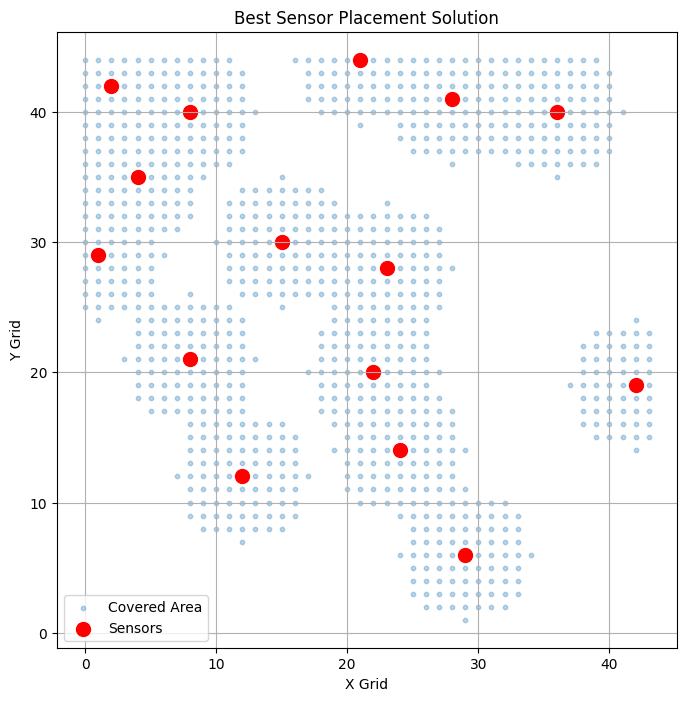


Generation 15


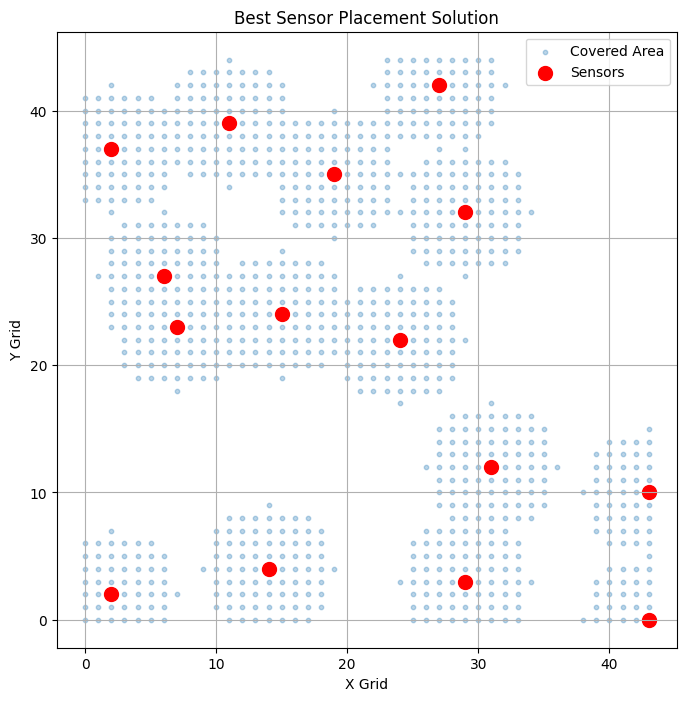


Generation 29


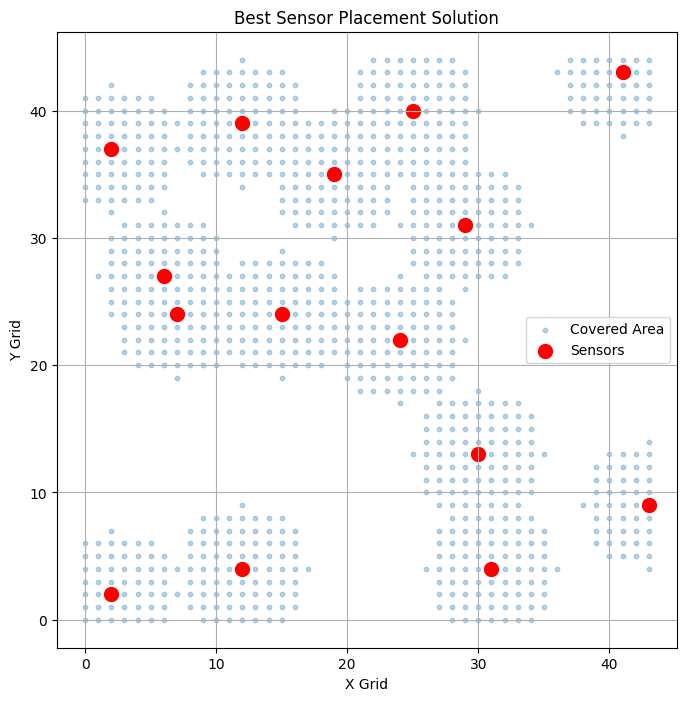


SUMMARY TABLE (Top Configurations)


,algorithm,selection,crossover,mutation,diversity,init,survivor,sensors,mean,std,max,seeds,scores
1208,HYBRID,tournament,uniform,shift,basic,random,elitism,15,19.788049,0.358083,20.039577,"[{'run': 0, 'seed': 86526}, {'run': 1, 'seed':...","[19.93705153886628, 20.00020278880203, 20.0395..."
1940,HYBRID,tournament,onepoint,shift,basic,heuristic,rank,15,19.550427,0.214969,19.943116,"[{'run': 0, 'seed': 3291}, {'run': 1, 'seed': ...","[19.52205513707425, 19.572708549015463, 19.336..."
440,HYBRID,tournament,uniform,shift,basic,random,rank,15,19.533001,0.418595,19.974262,"[{'run': 0, 'seed': 37636}, {'run': 1, 'seed':...","[19.632694886798898, 19.64228211909648, 18.734..."
1211,HYBRID,tournament,uniform,shift,basic,random,rank,15,19.509321,0.302450,19.951458,"[{'run': 0, 'seed': 15881}, {'run': 1, 'seed':...","[19.40950495239043, 19.031146200817275, 19.493..."
1499,HYBRID,over,uniform,shift,basic,random,rank,15,19.467185,0.383983,20.009121,"[{'run': 0, 'seed': 99391}, {'run': 1, 'seed':...","[20.009120600270016, 19.063884056779347, 19.04..."
650,HYBRID,sus,uniform,shift,strong,heuristic,rank,15,19.462693,0.641685,20.150735,"[{'run': 0, 'seed': 62200}, {'run': 1, 'seed':...","[19.02250174524669, 20.150734882754566, 18.435..."
1166,HYBRID,tournament,onepoint,shift,basic,heuristic,elitism,15,19.403262,0.378229,19.875659,"[{'run': 0, 'seed': 22529}, {'run': 1, 'seed':...","[19.875658586133994, 19.739008347548022, 18.80..."
1985,HYBRID,tournament,uniform,shift,basic,heuristic,elitism,15,19.394160,0.392028,20.066964,"[{'run': 0, 'seed': 89592}, {'run': 1, 'seed':...","[20.066963735372955, 19.19150749724415, 19.531..."
1217,HYBRID,tournament,uniform,shift,basic,heuristic,rank,15,19.340263,0.325339,19.599182,"[{'run': 0, 'seed': 30156}, {'run': 1, 'seed':...","[19.599182465652447, 18.69772763163233, 19.479..."
398,HYBRID,tournament,onepoint,shift,basic,heuristic,rank,15,19.336045,0.292216,19.792822,"[{'run': 0, 'seed': 22332}, {'run': 1, 'seed':...","[19.491616308506682, 19.341558506631248, 18.98..."


In [ ]:
import pandas as pd

# =========================
# 1. BEST CONFIGURATION OVERALL
# =========================
def get_best_config(results):
    return max(results, key=lambda x: x["max"])


# =========================
# 2. FIND BEST RUN (BEST SEED INSIDE CONFIG)
# =========================
def get_best_run(results):
    best_run = None
    best_score = -float("inf")

    for r in results:
        if "scores" in r:
            for i, s in enumerate(r["scores"]):
                if s > best_score:
                    best_score = s
                    best_run = {
                        "score": s,
                        "config": r,
                        "run_index": i,
                        "seed": r["seeds"][i] if isinstance(r["seeds"][i], dict) else r["seeds"][i]
                    }

    return best_run , best_score


# =========================
# 3. PRINT BEST INFO
# =========================
best_config = get_best_config(results)
best_run, _ = get_best_run(results)

print("\n" + "="*70)
print("BEST CONFIGURATION")
print("="*70)

print(f"Algorithm : {best_config['algorithm']}")
print(f"Sensors   : {best_config['sensors']}")
print(f"Mean      : {best_config['mean']:.4f}")
print(f"Max       : {best_config['max']:.4f}")

if best_config["algorithm"] != "DE":
    print(f"Selection : {best_config['selection']}")
    print(f"Crossover : {best_config['crossover']}")
    print(f"Mutation  : {best_config['mutation']}")
    print(f"Init      : {best_config['init']}")
    print(f"Diversity : {best_config['diversity']}")


print("\n" + "="*70)
print("BEST RUN (GLOBAL BEST SINGLE EXECUTION)")
print("="*70)

print(f"Best Score : {best_run['score']:.4f}")
print(f"Run Index  : {best_run['run_index']}")
print(f"Seed       : {best_run['seed']}")


# =========================
# 4. BEST SNAPSHOT VISUALIZATION
# =========================
config = best_run["config"]
algo = config["algorithm"]

if algo in ["GA", "HYBRID"]:

    all_algo_snapshots_entries = []
    for batch_snapshots_dict in snapshots:
        if algo in batch_snapshots_dict:
            all_algo_snapshots_entries.extend(batch_snapshots_dict[algo])

    # Reconstruct the config tuple for the best run to match the format stored in all_snapshots
    best_config_tuple = (
        config["selection"],
        config["crossover"],
        config["mutation"],
        config["diversity"],
        config["init"],
        config["survivor"],
        config["sensors"]
    )

    run_snapshots_collection_for_config = None
    for entry in all_algo_snapshots_entries:
        if entry["config"] == best_config_tuple:
            run_snapshots_collection_for_config = entry["runs"]
            break

    if run_snapshots_collection_for_config is not None:
        print("\n Showing best run evolution:")
        best_run_index = best_run["run_index"]
        correct_snapshots = run_snapshots_collection_for_config[best_run_index]

        for gen, sol in correct_snapshots:
            print(f"\nGeneration {gen}")
            visualize_best_solution(sol, grid, PARAMS["radius"])
    else:
        print("Could not find snapshots for the best run's configuration.")


# =========================
# 5. SUMMARY TABLE
# =========================
df = pd.DataFrame(results)

print("\n" + "="*70)
print("SUMMARY TABLE (Top Configurations)")
print("="*70)

display(df.sort_values("mean", ascending=False).head(10))

In [ ]:
def plot_results(results):

    labels = []
    means = []

    for r in results:
        label = f"{r['algorithm']}"
        if r['algorithm'] != "DE": # Only add these for GA and HYBRID
            label += f"-{r['selection']}-{r['crossover']}-{r['mutation']}-{r['diversity']}"
        labels.append(label)
        means.append(r["mean"])

    plt.figure(figsize=(24,12))
    plt.barh(labels, means)

    plt.title("GA vs DE vs HYBRID Comparison")
    plt.xlabel("Mean Fitness")
    plt.grid()

    plt.show()

In [ ]:
def plot_best_algorithms(results):

    best_ga = max([r for r in results if r["algorithm"]=="GA"], key=lambda x:x["mean"])
    best_de = max([r for r in results if r["algorithm"]=="DE"], key=lambda x:x["mean"])
    best_hybrid = max([r for r in results if r["algorithm"]=="HYBRID"], key=lambda x:x["mean"])

    labels = ["GA", "DE", "HYBRID"]
    values = [best_ga["mean"], best_de["mean"], best_hybrid["mean"]]

    plt.figure()
    plt.bar(labels, values)

    plt.title("Best Algorithm Comparison")
    plt.ylabel("Mean Fitness")

    plt.show()

In [ ]:
def plot_sensors_vs_fitness(results):

    sensors = []
    means = []

    for r in results:
        if "sensors" in r:
            sensors.append(r["sensors"])
            means.append(r["mean"])

    plt.figure()
    plt.plot(sensors, means, marker='o')

    plt.xlabel("Number of Sensors")
    plt.ylabel("Mean Fitness")
    plt.title("Sensor Count vs Performance")

    plt.grid()
    plt.show()

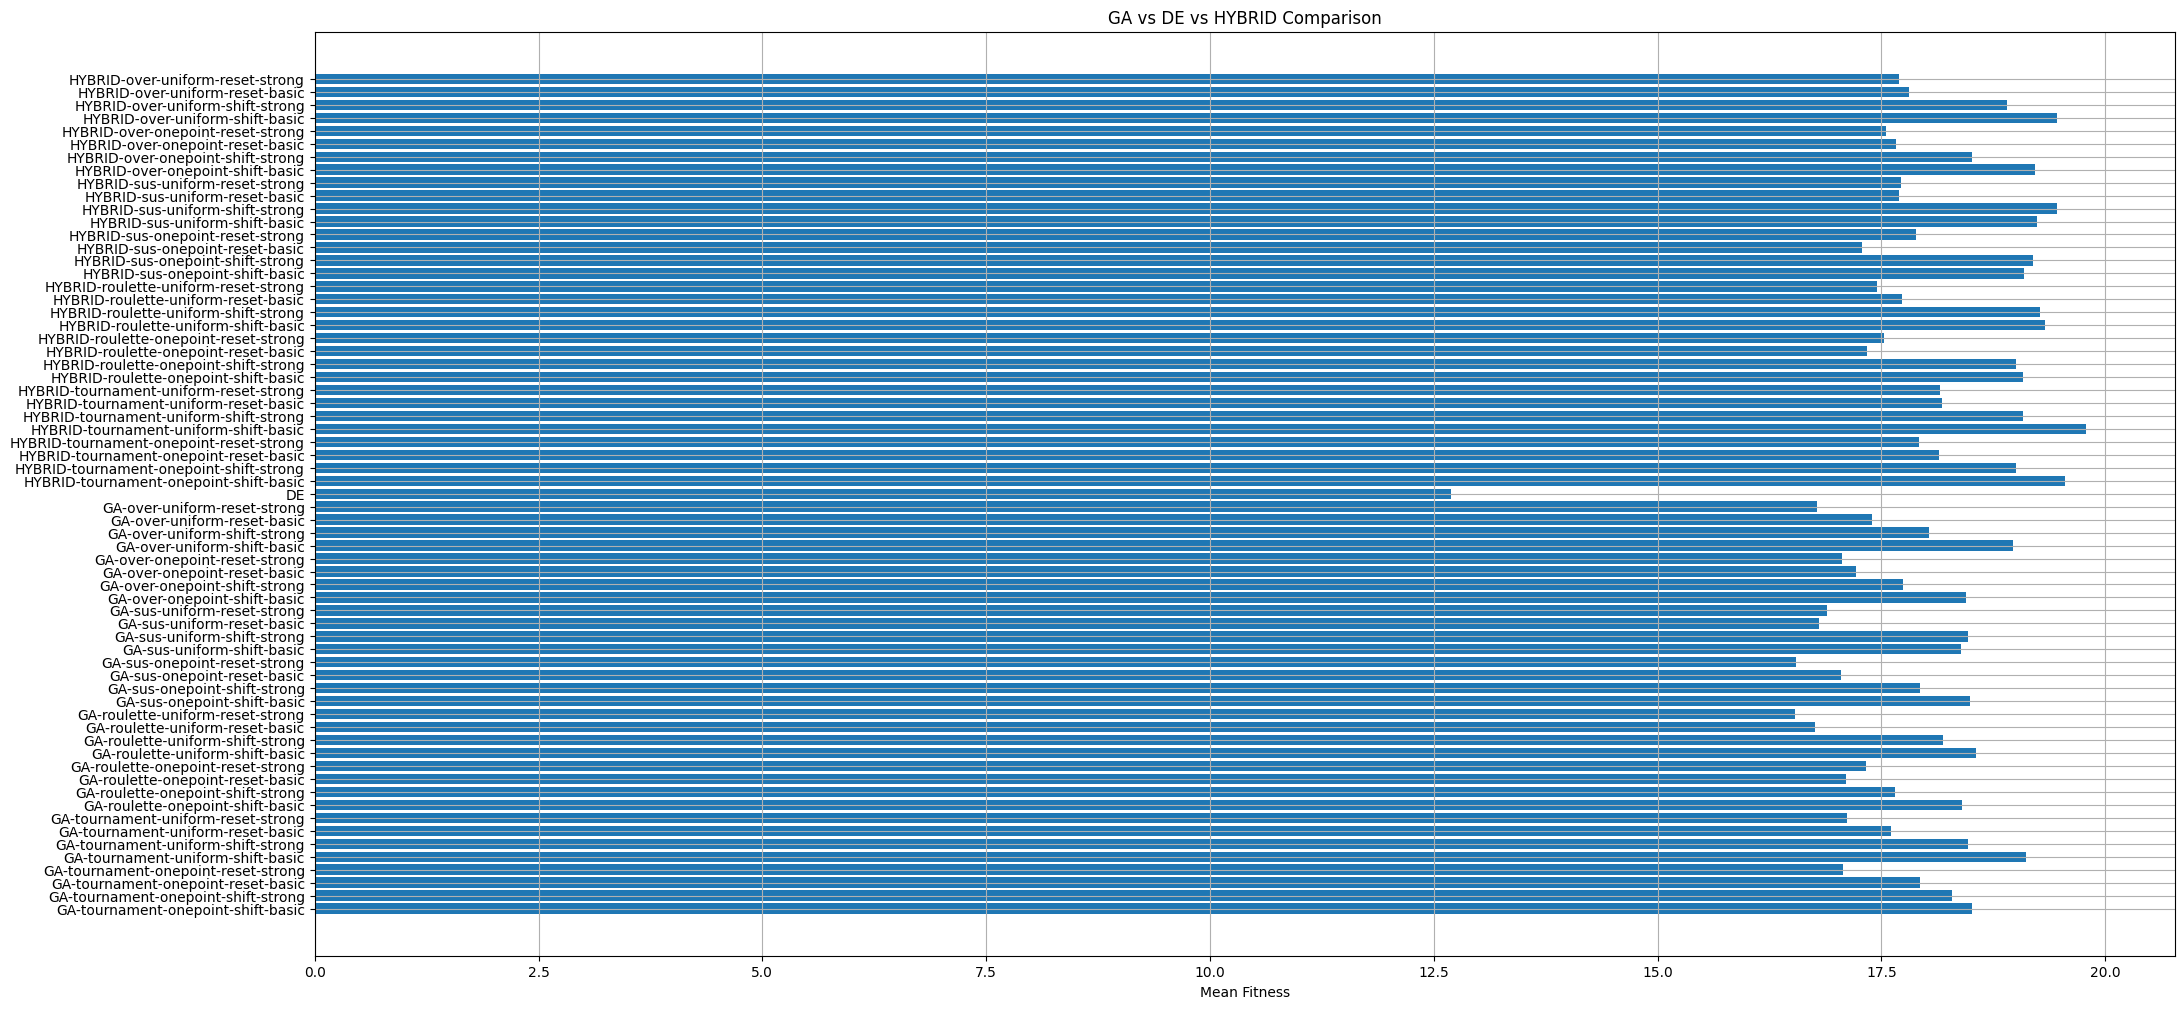

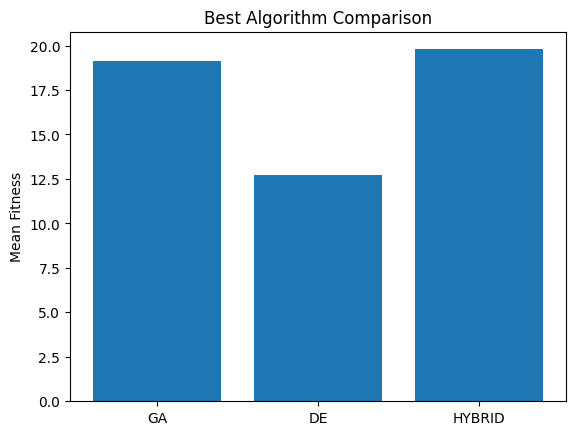

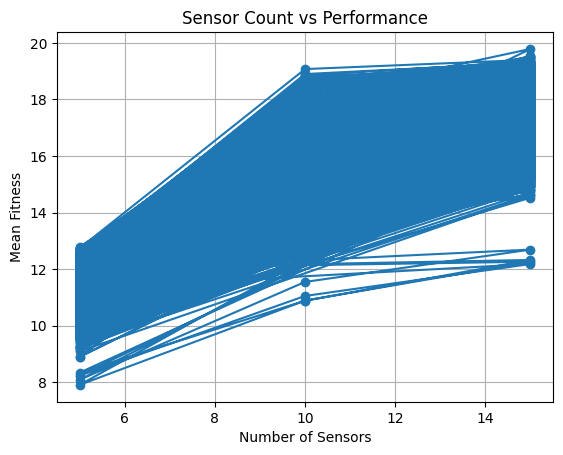

In [ ]:
plot_results(results)
plot_best_algorithms(results)
plot_sensors_vs_fitness(results)

In [ ]:
def average_histories(histories_list):
    return np.mean(histories_list, axis=0)
def plot_convergence(ga_hist, de_hist, hybrid_hist=None):

    plt.figure(figsize=(10,6))

    plt.plot(ga_hist, label="GA", linewidth=2)

    plt.plot(de_hist, label="DE", linewidth=2)

    if hybrid_hist is not None:
        plt.plot(hybrid_hist, label="Hybrid (GA+DE)", linewidth=2)

    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.title("Convergence Comparison")
    plt.legend()
    plt.grid(True)

    plt.show()

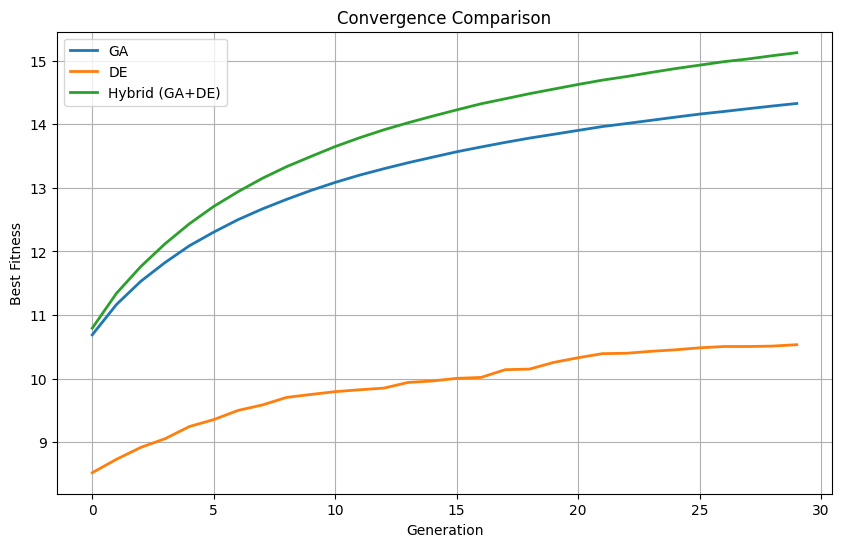

In [ ]:
# Collect all GA convergence curves from all batches and all configurations within each batch
all_ga_curves = []
for batch_hist_dict in histories:
    all_ga_curves.extend(batch_hist_dict["GA"])

# Collect all DE convergence curves
all_de_curves = []
for batch_hist_dict in histories:
    all_de_curves.extend(batch_hist_dict["DE"])

# Collect all HYBRID convergence curves
all_hybrid_curves = []
for batch_hist_dict in histories:
    all_hybrid_curves.extend(batch_hist_dict["HYBRID"])

ga_avg = average_histories(all_ga_curves)
de_avg = average_histories(all_de_curves)
hybrid_avg = average_histories(all_hybrid_curves)

plot_convergence(ga_avg, de_avg, hybrid_avg)

In [ ]:
def visualize_final_solution(chromosome, grid, R):

    n, m = grid.shape

    coverage_count = np.zeros((n, m))

    for (si, sj) in chromosome:
        for i in range(max(0, si-R), min(n, si+R+1)):
            for j in range(max(0, sj-R), min(m, sj+R+1)):

                if np.linalg.norm([si-i, sj-j]) <= R:
                    coverage_count[i][j] += 1

    sx = [x for x, y in chromosome]
    sy = [y for x, y in chromosome]

    plt.figure(figsize=(8,8))

    # background: coverage intensity
    plt.imshow(coverage_count, cmap="Blues", alpha=0.6, origin="lower")

    # sensors
    plt.scatter(sx, sy, c='red', s=120, label="Sensors")

    plt.title("Final Sensor Placement with Coverage Heatmap")
    plt.xlabel("X Grid")
    plt.ylabel("Y Grid")
    plt.legend()
    plt.grid(False)

    plt.show()


Generation 0


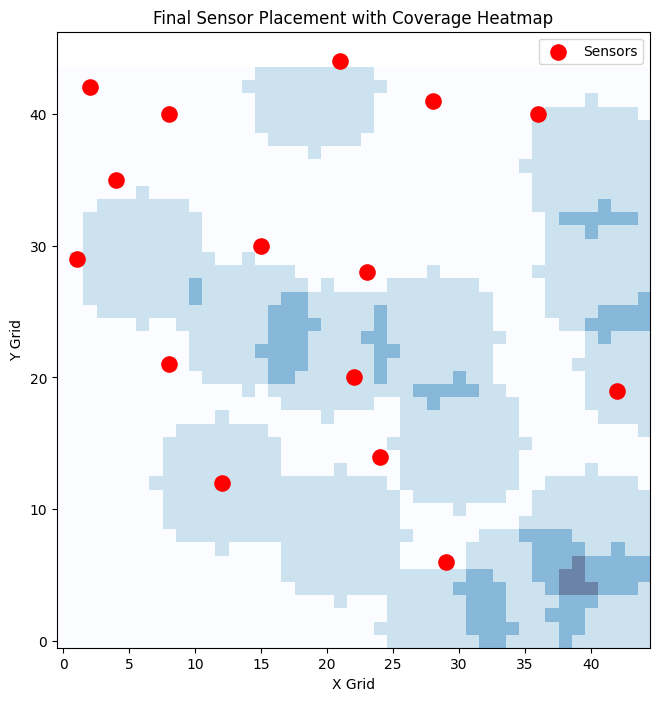


Generation 15


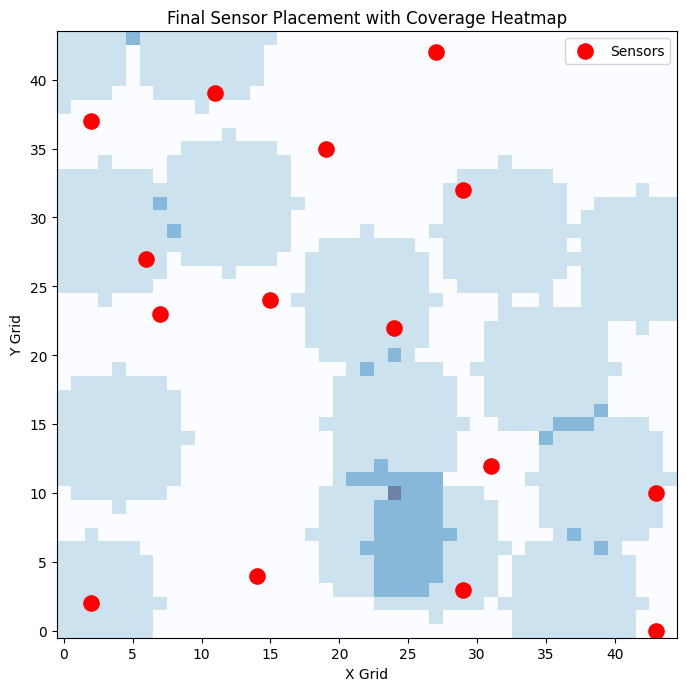


Generation 29


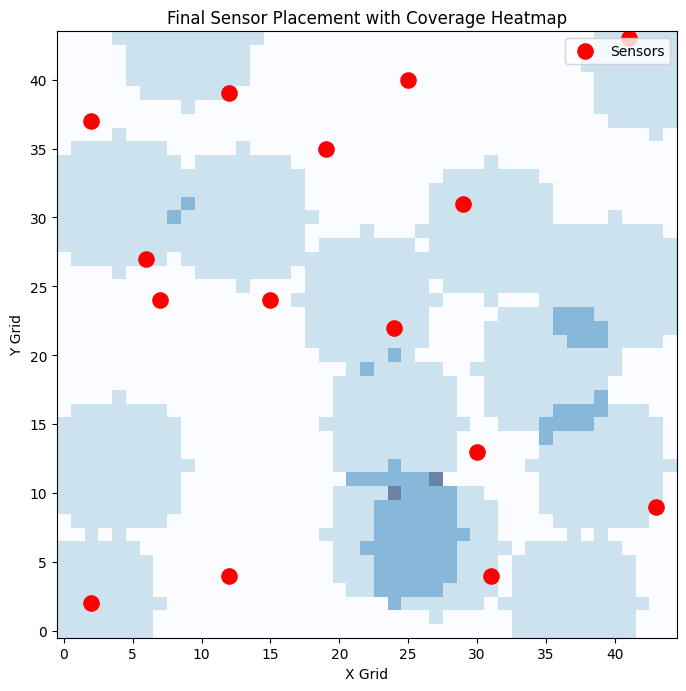

In [ ]:
# Get the configuration details of the best run
current_config = best_run["config"]
current_algo = current_config["algorithm"]

all_algo_snapshots_entries = []
# The global 'snapshots' variable (from run_in_batches) is a list of dictionaries (one per batch)
for batch_snapshots_dict in snapshots:
    if current_algo in batch_snapshots_dict:
        all_algo_snapshots_entries.extend(batch_snapshots_dict[current_algo])
best_config_tuple = (
    current_config["selection"],
    current_config["crossover"],
    current_config["mutation"],
    current_config["diversity"],
    current_config["init"],
    current_config["survivor"],
    current_config["sensors"]
)

run_snapshots_collection_for_config = None
for entry in all_algo_snapshots_entries:
    if entry["config"] == best_config_tuple:

        run_snapshots_collection_for_config = entry["runs"]
        break

if run_snapshots_collection_for_config is not None:
    best_run_index = best_run["run_index"]

    correct_snapshots = run_snapshots_collection_for_config[best_run_index]

    for gen, sol in correct_snapshots:
        print(f"\nGeneration {gen}")
        visualize_final_solution(sol, grid, PARAMS["radius"])
else:
    print("Could not find snapshots for the best run's configuration.")

In [ ]:
def plot_sensor_distribution(chromosome, grid):

    sx = [x for x, y in chromosome]
    sy = [y for x, y in chromosome]

    plt.figure(figsize=(7,7))

    # optional: background density
    plt.imshow(grid, cmap="Blues", alpha=0.5)

    plt.scatter(sx, sy, c='red', s=120, label="Sensors")

    plt.title("Sensor Distribution Map")
    plt.xlabel("X Grid")
    plt.ylabel("Y Grid")
    plt.legend()
    plt.grid(True)

    plt.show()

In [ ]:
def plot_coverage_heatmap(chromosome, grid, R):

    n, m = grid.shape
    coverage_count = np.zeros((n, m))

    for (si, sj) in chromosome:
        for i in range(max(0, si-R), min(n, si+R+1)):
            for j in range(max(0, sj-R), min(m, sj+R+1)):

                if np.linalg.norm([si-i, sj-j]) <= R:
                    coverage_count[i][j] += 1

    plt.figure(figsize=(8,6))

    plt.imshow(coverage_count, cmap="hot", origin="lower")

    plt.colorbar(label="Coverage Strength (Sensor Overlap)")

    plt.title("Coverage Heatmap")
    plt.xlabel("X Grid")
    plt.ylabel("Y Grid")

    plt.show()

In [ ]:
def plot_uncovered_heatmap(chromosome, grid, R):

    n, m = grid.shape
    covered = set()

    for (si, sj) in chromosome:
        for i in range(max(0, si-R), min(n, si+R+1)):
            for j in range(max(0, sj-R), min(m, sj+R+1)):

                if np.linalg.norm([si-i, sj-j]) <= R:
                    covered.add((i, j))

    uncovered = np.zeros((n, m))

    for i in range(n):
        for j in range(m):
            if (i, j) not in covered:
                uncovered[i][j] = 1

    plt.figure(figsize=(8,6))

    plt.imshow(uncovered, cmap="Reds", origin="lower")

    plt.title("Uncovered Areas Heatmap")
    plt.xlabel("X Grid")
    plt.ylabel("Y Grid")

    plt.show()

In [ ]:
best_solution = None
best_score = -float("inf")

if run_snapshots_collection_for_config is not None:

    best_run_index = best_run["run_index"]
    correct_snapshots = run_snapshots_collection_for_config[best_run_index]

    for gen, sol in correct_snapshots:

        score = coverage_ratio(sol, grid, PARAMS["radius"])

        if score > best_score:
            best_score = score
            best_solution = sol

In [ ]:
best, hist, avg, best_solution, div_hist, snapshots = run_ga(
    grid,
    selection_method=best_config["selection"],
    crossover_type=best_config["crossover"],
    mutation_type=best_config["mutation"],
    diversity_type=best_config["diversity"],
    init_method=best_config["init"],
    survivor_method=best_config["survivor"],
    num_sensors=20,
    use_de=True,
    seed=42
)


    Generation 0
    Mutation Rate   : 0.200
    Crossover Rate  : 0.900
    Tournament K    : 7
    
Diversity = 12.1433
[GA+DE] Gen 00 | Best=12.8177 | Avg=8.8639

    Generation 1
    Mutation Rate   : 0.197
    Crossover Rate  : 0.887
    Tournament K    : 6
    
Diversity = 11.2150
[GA+DE] Gen 01 | Best=11.5865 | Avg=9.3316

    Generation 2
    Mutation Rate   : 0.193
    Crossover Rate  : 0.873
    Tournament K    : 6
    
Diversity = 10.6619
[GA+DE] Gen 02 | Best=11.7728 | Avg=10.1697

    Generation 3
    Mutation Rate   : 0.190
    Crossover Rate  : 0.860
    Tournament K    : 6
    
Diversity = 10.2890
[GA+DE] Gen 03 | Best=11.5317 | Avg=10.5193

    Generation 4
    Mutation Rate   : 0.187
    Crossover Rate  : 0.847
    Tournament K    : 6
    
Diversity = 9.1772
[GA+DE] Gen 04 | Best=12.8479 | Avg=11.3575

    Generation 5
    Mutation Rate   : 0.183
    Crossover Rate  : 0.833
    Tournament K    : 6
    
Diversity = 8.3694
[GA+DE] Gen 05 | Best=15.6884 | Avg=11.7404

 

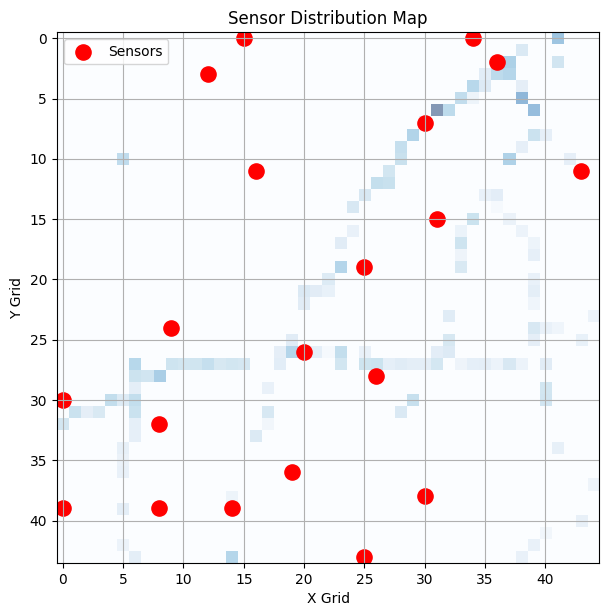

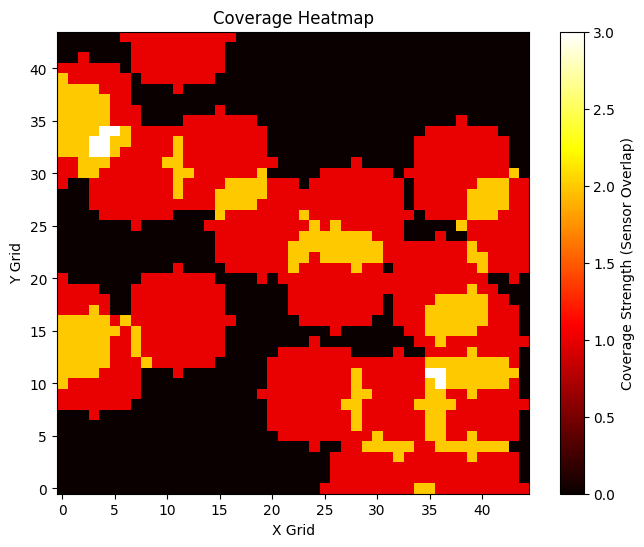

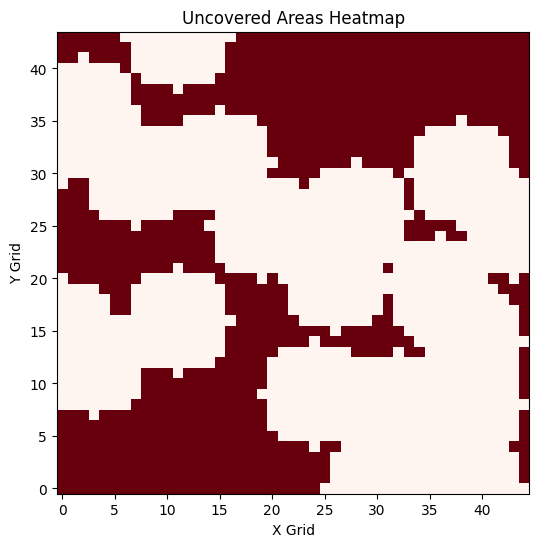

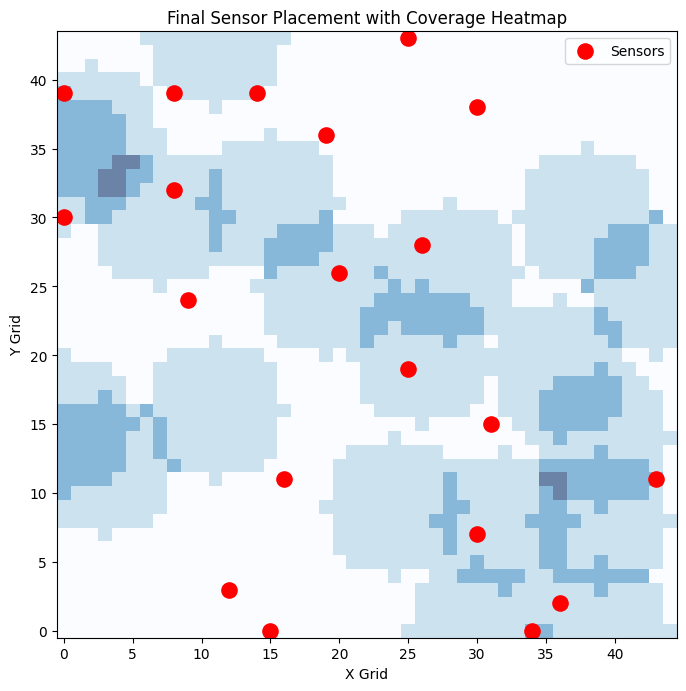

In [ ]:
best_score = coverage_ratio(best_solution, grid, PARAMS["radius"])
plot_sensor_distribution(best_solution, grid)
plot_coverage_heatmap(best_solution, grid, PARAMS["radius"])
plot_uncovered_heatmap(best_solution, grid, PARAMS["radius"])
visualize_final_solution(best_solution, grid, PARAMS["radius"])

In [ ]:
import joblib

# SAVE
joblib.dump(results, "results.pkl")
joblib.dump(histories, "histories.pkl")
joblib.dump(snapshots, "snapshots.pkl")
joblib.dump(diversity, "diversity.pkl")

print("Saved successfully!")

Saved successfully!


In [ ]:
import pandas as pd

df = pd.DataFrame(results)
df.to_csv("results_summary.csv", index=False)

print("CSV saved!")

CSV saved!
